# SOS Baby Monitor — v2 Training Notebook

## ארכיטקטורת הדאטה
| שכבה | דאטהסט | תפקיד | יציבות |
|------|---------|--------|--------|
| 1 | Donate-a-Cry | ~750 קטעי בכי | ✅ יציב |
| 1 | ESC-50 | 40 בכי + 1960 רקע מגוון | ✅ יציב |
| 1 | MUSAN noise+speech | רקע: רעש + דיבור | ✅ יציב |
| 2 | AudioSet Baby Cry | בכי מיוטיוב אמיתי | ⚡ best-effort |
| 3 | ICSD HuggingFace | בכי תינוקות נוסף | ⚡ best-effort |

## הוראות
1. ודאי שה-Runtime מוגדר ל-**GPU** (Runtime → Change runtime type → T4 GPU)
2. הריצי תא אחר תא לפי הסדר
3. תאים 6 ו-7 יכולים לכשול — זה בסדר, הסקריפט ממשיך
4. בסוף תוריגי `sos_model.keras` ו-`norm_stats.json` ותשמרי ב-`models/`

## שימוש בדיסק (Colab חינמי)
| שלב | שימוש משוער |
|------|-------------|
| בזמן הורדות | ~5GB |
| אחרי preprocessing + ניקוי | ~150MB |
| **מגבלת Colab** | **78GB** |

✅ נמצאים בנוח — תא 9b מוחק את ה-raw audio אוטומטית אחרי ה-preprocessing.


## תא 1: התקנת ספריות


In [1]:
# ===== תא 1: התקנת ספריות =====
!pip install -q librosa soundfile gdown
!pip install -q yt-dlp
!pip install -q datasets huggingface_hub
import subprocess, sys
# וידוא ffmpeg קיים (נחוץ ל-yt-dlp)
result = subprocess.run(['ffmpeg', '-version'], capture_output=True)
if result.returncode != 0:
    !apt-get install -q -y ffmpeg
print('✅ ספריות + ffmpeg מוכנים')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.6 MB/s eta 0:00:00
✅ ספריות + ffmpeg מוכנים


## תא 2: הגדרת תיקיות וקבועים


In [2]:
# ===== תא 2: הגדרת תיקיות וקבועים גלובליים =====
import os

BASE       = '/content/data'
RAW_CRY    = f'{BASE}/raw/crying'
RAW_BG     = f'{BASE}/raw/background'
PROCESSED  = f'{BASE}/processed'
MODELS_OUT = '/content/models'
LOG        = {}   # יישמור כמה קבצים נאספו מכל מקור

for d in [RAW_CRY, RAW_BG, PROCESSED, MODELS_OUT]:
    os.makedirs(d, exist_ok=True)

SR         = 22050
DURATION   = 2.0
N_MELS     = 128
SUPPORTED  = ('.wav', '.mp3', '.ogg', '.flac', '.m4a', '.3gp')

print('📂 תיקיות נוצרו')
print(f'   crying    → {RAW_CRY}')
print(f'   background→ {RAW_BG}')
print(f'   processed → {PROCESSED}')


📂 תיקיות נוצרו
   crying    → /content/data/raw/crying
   background→ /content/data/raw/background
   processed → /content/data/processed


## תא 3 | שכבה 1 — Donate-a-Cry


In [3]:
# ===== תא 3: שכבה 1 — Donate-a-Cry (GitHub) =====
# ~750 קטעי בכי, הורדה ישירה כ-ZIP מ-GitHub Releases
import zipfile, glob, shutil

DAC_ZIP = '/content/donateacry.zip'
DAC_URL = 'https://github.com/gveres/donateacry-corpus/archive/refs/heads/master.zip'

print('⬇️  מוריד Donate-a-Cry...')
!wget -q -O {DAC_ZIP} {DAC_URL}

print('📦 מחלץ...')
with zipfile.ZipFile(DAC_ZIP, 'r') as z:
    z.extractall('/content/dac_tmp')
os.remove(DAC_ZIP)

# העתקת כל ה-wav לתיקיית crying
copied = 0
for f in glob.glob('/content/dac_tmp/**/*.wav', recursive=True):
    dest = os.path.join(RAW_CRY, f'dac_{os.path.basename(f)}')
    if not os.path.exists(dest):
        shutil.copy2(f, dest)
        copied += 1

shutil.rmtree('/content/dac_tmp', ignore_errors=True)
LOG['donate_a_cry'] = copied
print(f'✅ Donate-a-Cry: {copied} קבצים הועתקו → {RAW_CRY}')


⬇️  מוריד Donate-a-Cry...
📦 מחלץ...
✅ Donate-a-Cry: 457 קבצים הועתקו → /content/data/raw/crying


## תא 4 | שכבה 1 — ESC-50


In [4]:
# ===== תא 4: שכבה 1 — ESC-50 (GitHub) =====
# 40 קטעי בכי + 1960 רקע מגוון (ציפורים, גשם, שאיבת אבק, כלבים, ילדים...)
# נשתמש ב-CSV כדי לסנן לפי קטגוריה בלבד
import zipfile, shutil, csv

ESC_ZIP = '/content/esc50.zip'
ESC_URL = 'https://github.com/karolpiczak/ESC-50/archive/refs/heads/master.zip'

# קטגוריות שהולכות לבכי
CRY_CATS = {'crying_baby'}

# קטגוריות שהולכות לרקע — כל השאר חוץ מ-crying_baby
# (50 קטגוריות סה"כ, נסנן דינמית לפי ה-CSV)

print('⬇️  מוריד ESC-50...')
!wget -q -O {ESC_ZIP} {ESC_URL}

print('📦 מחלץ...')
with zipfile.ZipFile(ESC_ZIP, 'r') as z:
    z.extractall('/content/esc_tmp')
os.remove(ESC_ZIP)

# קריאת ה-metadata
csv_path  = '/content/esc_tmp/ESC-50-master/meta/esc50.csv'
audio_dir = '/content/esc_tmp/ESC-50-master/audio'

cry_copied = 0
bg_copied  = 0

with open(csv_path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        src  = os.path.join(audio_dir, row['filename'])
        cat  = row['category']
        if not os.path.exists(src):
            continue
        if cat in CRY_CATS:
            dest = os.path.join(RAW_CRY, f'esc50_{row["filename"]}')
            if not os.path.exists(dest):
                shutil.copy2(src, dest)
                cry_copied += 1
        else:
            dest = os.path.join(RAW_BG, f'esc50_{row["filename"]}')
            if not os.path.exists(dest):
                shutil.copy2(src, dest)
                bg_copied += 1

shutil.rmtree('/content/esc_tmp', ignore_errors=True)
LOG['esc50_cry'] = cry_copied
LOG['esc50_bg']  = bg_copied
print(f'✅ ESC-50: crying={cry_copied}, background={bg_copied}')


⬇️  מוריד ESC-50...
📦 מחלץ...
✅ ESC-50: crying=40, background=1960


## תא 5 | שכבה 1 — MUSAN (noise + speech)


In [5]:
# ===== תא 5: רקע מגוון דרך AudioSet yt-dlp =====
import csv, subprocess, os, urllib.request
from collections import defaultdict

MAX_PER_LABEL = 120

BG_LABELS = {
    '/m/09x0r':  'speech',
    '/m/04rlf':  'music',
    '/m/07qfr4h':'tv_radio',
    '/m/02dgv':  'door',
    '/m/0284vy3':'washing',
    '/m/01g50p':  'vacuum',
    '/m/03l9g':  'dog',
    '/m/01dwxx':  'crowd',
    '/m/0jb2l':  'siren',
    '/m/07pws3f':'fan',
}

SEGMENTS_URL = 'http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/balanced_train_segments.csv'

print('⬇️  מוריד AudioSet CSV...')
with urllib.request.urlopen(SEGMENTS_URL) as resp:
    raw = resp.read().decode('utf-8')

lines = [l for l in raw.splitlines() if not l.startswith('#')]
reader = csv.reader(lines)
next(reader)

label_segments = defaultdict(list)
for row in reader:
    if len(row) < 4:
        continue
    ytid, start, end, labels = row[0].strip(), float(row[1]), float(row[2]), row[3]
    for label_id, label_name in BG_LABELS.items():
        if label_id in labels:
            label_segments[label_name].append((ytid, start, end))
            break

for name, segs in label_segments.items():
    print(f'  {name}: {len(segs)} segments זמינים')

downloaded = 0
failed     = 0

for label_name, segments in label_segments.items():
    label_count = 0
    for ytid, start, end in segments:
        if label_count >= MAX_PER_LABEL:
            break
        out_path = os.path.join(RAW_BG, f'audioset_{label_name}_{ytid}_{int(start)}.wav')
        if os.path.exists(out_path):
            label_count += 1
            downloaded += 1
            continue
        cmd = [
            'yt-dlp', '--quiet', '--no-warnings',
            '--extract-audio', '--audio-format', 'wav',
            '--postprocessor-args', f'-ss {start} -to {end} -ar 22050 -ac 1',
            '-o', out_path,
            '--socket-timeout', '15',
            f'https://www.youtube.com/watch?v={ytid}'
        ]
        try:
            subprocess.run(cmd, timeout=25, capture_output=True)
            if os.path.exists(out_path) and os.path.getsize(out_path) > 1000:
                label_count += 1
                downloaded += 1
            else:
                failed += 1
        except Exception:
            failed += 1
    print(f'  ✅ {label_name}: {label_count} הורדו')

LOG['audioset_bg'] = downloaded
print(f'\n✅ AudioSet Background: {downloaded} הורדו, {failed} נכשלו')
print(f'   (נכשלות = סרטונים שנמחקו מיוטיוב — תקין לחלוטין)')


⬇️  מוריד AudioSet CSV...
  music: 3337 segments זמינים
  speech: 554 segments זמינים
  fan: 17 segments זמינים
  dog: 57 segments זמינים
  siren: 5 segments זמינים
  vacuum: 125 segments זמינים
  door: 60 segments זמינים
  tv_radio: 38 segments זמינים
  washing: 5 segments זמינים
  ✅ music: 120 הורדו
  ✅ speech: 120 הורדו
  ✅ fan: 9 הורדו
  ✅ dog: 36 הורדו
  ✅ siren: 0 הורדו
  ✅ vacuum: 83 הורדו
  ✅ door: 40 הורדו
  ✅ tv_radio: 16 הורדו
  ✅ washing: 3 הורדו

✅ AudioSet Background: 427 הורדו, 317 נכשלו
   (נכשלות = סרטונים שנמחקו מיוטיוב — תקין לחלוטין)


## תא 6 | שכבה 2 — AudioSet Baby Cry (yt-dlp)


In [6]:
# ===== תא 6: שכבה 2 — AudioSet Baby Cry via yt-dlp (best-effort) =====
# מוריד את ה-segments CSV של AudioSet, מסנן לפי label "Baby cry, infant cry",
# ואז מוריד כל קטע מיוטיוב עם yt-dlp + ffmpeg
# קטעים שנמחקו מיוטיוב — מדולגים אוטומטית. timeout = 25 שניות לסרטון.

import csv, subprocess, io, urllib.request

MAX_AUDIOSET_CRY = 300   # מקסימום קטעים שנוריד

# Label ID של "Baby cry, infant cry" ב-AudioSet ontology
BABY_CRY_LABEL = '/m/0k65p'

# קובץ ה-CSV של balanced train segments
SEGMENTS_URL = 'http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/balanced_train_segments.csv'

print('⬇️  מוריד AudioSet balanced_train_segments.csv...')
with urllib.request.urlopen(SEGMENTS_URL) as resp:
    raw = resp.read().decode('utf-8')

# ה-CSV מתחיל ב-3 שורות comment — מדלגים
lines = [l for l in raw.splitlines() if not l.startswith('#')]
reader = csv.reader(lines)
next(reader)  # header

segments = []
for row in reader:
    if len(row) < 4:
        continue
    ytid, start, end, labels = row[0].strip(), float(row[1]), float(row[2]), row[3]
    if BABY_CRY_LABEL in labels:
        segments.append((ytid, start, end))

print(f'🎯 נמצאו {len(segments)} Baby cry segments ב-AudioSet')
print(f'   מנסה להוריד עד {MAX_AUDIOSET_CRY} מהם...')

downloaded = 0
failed     = 0

for ytid, start, end in segments[:MAX_AUDIOSET_CRY]:
    out_path = os.path.join(RAW_CRY, f'audioset_{ytid}_{int(start)}.wav')
    if os.path.exists(out_path):
        downloaded += 1
        continue
    url = f'https://www.youtube.com/watch?v={ytid}'
    # yt-dlp: מוריד רק את ה-segment הרלוונטי, ממיר ל-wav 22050Hz mono
    cmd = [
        'yt-dlp',
        '--quiet',
        '--no-warnings',
        '--extract-audio',
        '--audio-format', 'wav',
        '--postprocessor-args', f'-ss {start} -to {end} -ar 22050 -ac 1',
        '-o', out_path,
        '--socket-timeout', '15',
        url
    ]
    try:
        result = subprocess.run(cmd, timeout=25, capture_output=True)
        if os.path.exists(out_path) and os.path.getsize(out_path) > 1000:
            downloaded += 1
            if downloaded % 20 == 0:
                print(f'   ⬇️  {downloaded}/{MAX_AUDIOSET_CRY} הורדו...')
        else:
            failed += 1
    except subprocess.TimeoutExpired:
        failed += 1
    except Exception:
        failed += 1

LOG['audioset_cry'] = downloaded
print(f'\n✅ AudioSet Baby Cry: {downloaded} הורדו, {failed} נכשלו (נמחקו מיוטיוב / timeout)')


⬇️  מוריד AudioSet balanced_train_segments.csv...
🎯 נמצאו 24 Baby cry segments ב-AudioSet
   מנסה להוריד עד 300 מהם...

✅ AudioSet Baby Cry: 8 הורדו, 16 נכשלו (נמחקו מיוטיוב / timeout)


## תא 7 | שכבה 3 — ICSD (HuggingFace)


In [7]:
# ===== תא 7: שכבה 3 — ICSD מ-HuggingFace (best-effort) =====
# ICSD = Infant Cry and Snoring Detection dataset
# מכיל 4+ שעות אודיו של בכי תינוקות ונחירות
# אם ה-download נכשל (גישה מוגבלת וכו') — ממשיכים בלעדיו

try:
    from datasets import load_dataset
    import soundfile as sf
    import numpy as np

    print('⬇️  מנסה לטעון ICSD מ-HuggingFace...')
    # טוען רק את ה-subset של infant cry, streaming כדי לחסוך זיכרון
    ds = load_dataset(
        'QingyuLiu1/ICSD',
        split='train',
        streaming=True,
        trust_remote_code=True
    )

    icsd_copied = 0
    MAX_ICSD = 400

    for i, sample in enumerate(ds):
        if icsd_copied >= MAX_ICSD:
            break
        # מסנן רק infant_cry (לא snoring)
        label = str(sample.get('label', sample.get('event_label', '')))
        if 'cry' not in label.lower() and 'infant' not in label.lower():
            continue
        audio_arr = sample['audio']['array']
        sr_orig   = sample['audio']['sampling_rate']
        import librosa as _lb
        if sr_orig != 22050:
            audio_arr = _lb.resample(audio_arr.astype(np.float32), orig_sr=sr_orig, target_sr=22050)
        out_path = os.path.join(RAW_CRY, f'icsd_{i:05d}.wav')
        if not os.path.exists(out_path):
            sf.write(out_path, audio_arr, 22050)
            icsd_copied += 1

    LOG['icsd'] = icsd_copied
    print(f'✅ ICSD: {icsd_copied} קבצים → {RAW_CRY}')

except Exception as e:
    LOG['icsd'] = 0
    print(f'⚠️  ICSD לא זמין ({type(e).__name__}: {e})')
    print('   ממשיכים בלעדיו — זה בסדר לחלוטין.')


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'QingyuLiu1/ICSD' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'QingyuLiu1/ICSD' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⬇️  מנסה לטעון ICSD מ-HuggingFace...


README.md:   0%|          | 0.00/5.08k [00:00<?, ?B/s]

⚠️  ICSD לא זמין (DatasetNotFoundError: Dataset 'QingyuLiu1/ICSD' is a gated dataset on the Hub. You must be authenticated to access it.)
   ממשיכים בלעדיו — זה בסדר לחלוטין.


## תא 8: סיכום נתונים שנאספו


In [8]:
# ===== תא 8: סיכום הנתונים שנאספו =====
import glob

def count_files(directory):
    return len([f for f in glob.glob(os.path.join(directory, '**', '*'), recursive=True)
                if os.path.isfile(f) and f.lower().endswith(SUPPORTED)])

cry_total = count_files(RAW_CRY)
bg_total  = count_files(RAW_BG)

print('=' * 50)
print('📊 סיכום נתונים שנאספו:')
print('=' * 50)
print(f'\n🍼 CRYING ({cry_total} קבצים סה"כ):')
print(f'   Donate-a-Cry : {LOG.get("donate_a_cry", 0)}')
print(f'   ESC-50        : {LOG.get("esc50_cry", 0)}')
print(f'   AudioSet      : {LOG.get("audioset_cry", 0)}')
print(f'   ICSD          : {LOG.get("icsd", 0)}')

print(f'\n🔊 BACKGROUND ({bg_total} קבצים סה"כ):')
print(f'   ESC-50        : {LOG.get("esc50_bg", 0)}')
print(f'   MUSAN         : {LOG.get("musan", 0)}')

print('\n' + '=' * 50)

if cry_total < 300:
    print('⚠️  WARNING: פחות מ-300 קטעי בכי — כדאי לבדוק מה נכשל בתאים 3-7')
elif cry_total < 600:
    print('🟡 בינוני: יש מספיק לאמן, אבל עוד בכי ישפר.')
else:
    print('✅ מעולה! יש מספיק גיוון לאמן מודל חזק.')

if bg_total < cry_total:
    print('⚠️  WARNING: יש פחות background מ-crying — הוסיפי MUSAN manually')


📊 סיכום נתונים שנאספו:

🍼 CRYING (510 קבצים סה"כ):
   Donate-a-Cry : 457
   ESC-50        : 40
   AudioSet      : 8
   ICSD          : 0

🔊 BACKGROUND (2519 קבצים סה"כ):
   ESC-50        : 1960
   MUSAN         : 0

🟡 בינוני: יש מספיק לאמן, אבל עוד בכי ישפר.


## תא 9: Preprocessing → Mel-Spectrogram


In [9]:
import numpy as np
import librosa
import warnings
import os
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

CAT_DIRS   = {'crying': RAW_CRY, 'background': RAW_BG}
STRIDE_SEC = 1.0

def file_to_segments(path, sr, duration, stride):
    try:
        audio, _ = librosa.load(path, sr=sr, mono=True)
    except Exception:
        return []
    target_len = int(sr * duration)
    stride_len = int(sr * stride)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
        return [audio]
    segments = []
    start = 0
    while start + target_len <= len(audio):
        segments.append(audio[start:start + target_len])
        start += stride_len
    return segments

def audio_to_mel(audio, sr, n_mels):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
    return librosa.power_to_db(mel, ref=np.max)

train_items = []
test_items  = []

for label, category in enumerate(['crying', 'background']):
    cat_dir   = CAT_DIRS[category]
    all_files = [f for f in os.listdir(cat_dir) if f.lower().endswith(SUPPORTED)]
    train_files, test_files = train_test_split(all_files, test_size=0.20, random_state=42)

    for split_name, file_list in [('train', train_files), ('test', test_files)]:
        for filename in file_list:
            src      = os.path.join(cat_dir, filename)
            segments = file_to_segments(src, SR, DURATION, STRIDE_SEC)
            for seg in segments:
                try:
                    mel = audio_to_mel(seg, SR, N_MELS)
                    if split_name == 'train':
                        train_items.append((mel, label))
                    else:
                        test_items.append((mel, label))
                except Exception:
                    pass

print(f'Train: {len(train_items)} | Test: {len(test_items)}')
print(f'  crying train:     {sum(1 for _,l in train_items if l==0)}')
print(f'  background train: {sum(1 for _,l in train_items if l==1)}')
print(f'  crying test:      {sum(1 for _,l in test_items  if l==0)}')
print(f'  background test:  {sum(1 for _,l in test_items  if l==1)}')


Train: 11540 | Test: 2887
  crying train:     2192
  background train: 9348
  crying test:      537
  background test:  2350


## תא 9b: ניקוי Raw Audio (חיסכון בדיסק)


In [10]:
import shutil, os

def du_mb(path):
    total = 0
    for f in os.scandir(path):
        if f.is_file():
            total += f.stat().st_size
    return total / 1024 / 1024

before_cry = du_mb(RAW_CRY)
before_bg  = du_mb(RAW_BG)
print(f'לפני מחיקה: crying={before_cry:.0f}MB, background={before_bg:.0f}MB')

shutil.rmtree(RAW_CRY)
shutil.rmtree(RAW_BG)

import shutil as _sh
total, used, free = _sh.disk_usage('/')
print(f'דיסק חופשי: {free/1024**3:.1f}GB / {total/1024**3:.1f}GB')
print('✅ Raw audio נמחק')


לפני מחיקה: crying=68MB, background=1000MB
דיסק חופשי: 65.9GB / 112.6GB
✅ Raw audio נמחק


## תא 10: נורמליזציה + Train/Test Split


In [11]:
import numpy as np
import json

X_train = np.array([m for m,_ in train_items], dtype=np.float32)
y_train = np.array([l for _,l in train_items])
X_test  = np.array([m for m,_ in test_items],  dtype=np.float32)
y_test  = np.array([l for _,l in test_items])

MEAN = float(X_train.mean())
STD  = float(X_train.std())
print(f'נרמול (מ-train בלבד): mean={MEAN:.2f}, std={STD:.2f}')

with open(os.path.join(MODELS_OUT, 'norm_stats.json'), 'w') as f:
    json.dump({'mean': MEAN, 'std': STD}, f)
print(f'✅ norm_stats.json נשמר ב-{MODELS_OUT}')

X_train = (X_train - MEAN) / (STD + 1e-8)
X_test  = (X_test  - MEAN) / (STD + 1e-8)
X_train = X_train[..., np.newaxis]
X_test  = X_test [..., np.newaxis]

print(f'צורה אחרי נרמול: train={X_train.shape}, test={X_test.shape}')


נרמול (מ-train בלבד): mean=-42.77, std=21.41
✅ norm_stats.json נשמר ב-/content/models
צורה אחרי נרמול: train=(11540, 128, 87, 1), test=(2887, 128, 87, 1)


## תא 11: הגדרת Augmentation


In [12]:
import numpy as np
from tensorflow import keras

def specaugment_freq_mask(mel, num_masks=2, F=15):
    out = mel.copy()
    n_mels = mel.shape[0]
    for _ in range(num_masks):
        f  = np.random.randint(0, F)
        f0 = np.random.randint(0, n_mels - f)
        out[f0:f0+f, :, :] = 0.0
    return out

def specaugment_time_mask(mel, num_masks=2, T=15):
    out = mel.copy()
    n_time = mel.shape[1]
    for _ in range(num_masks):
        t  = np.random.randint(0, T)
        t0 = np.random.randint(0, n_time - t)
        out[:, t0:t0+t, :] = 0.0
    return out

def augment_crying_only(X_train, y_train_cat):
    cry_mask = (y_train_cat[:, 0] == 1)
    X_cry    = X_train[cry_mask]
    y_cry    = y_train_cat[cry_mask]

    augmented_X = [X_train]
    augmented_y = [y_train_cat]

    augmented_X.append(X_cry + np.random.normal(0, 0.02, X_cry.shape).astype(np.float32))
    augmented_y.append(y_cry)

    augmented_X.append(np.roll(X_cry, shift=np.random.randint(5, 20), axis=2))
    augmented_y.append(y_cry)

    scales = np.random.uniform(0.7, 1.3, (len(X_cry), 1, 1, 1)).astype(np.float32)
    augmented_X.append(X_cry * scales)
    augmented_y.append(y_cry)

    spec_aug = np.array([specaugment_freq_mask(specaugment_time_mask(x)) for x in X_cry])
    augmented_X.append(spec_aug)
    augmented_y.append(y_cry)

    return np.concatenate(augmented_X), np.concatenate(augmented_y)

print('✅ פונקציות augmentation מוכנות')


✅ פונקציות augmentation מוכנות


## תא 12: הגדרת המודל


In [15]:
# ===== תא 12: הגדרת המודל =====
import tensorflow as tf
from tensorflow import keras
import numpy as np

print(f'GPU זמין: {len(tf.config.list_physical_devices("GPU")) > 0}')

y_cat_train = keras.utils.to_categorical(y_train, num_classes=2)
y_cat_test  = keras.utils.to_categorical(y_test,  num_classes=2)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

X_train_aug, y_train_aug = augment_crying_only(X_train, y_cat_train)
print(f'אחרי augmentation: {len(X_train_aug)} דוגמאות')
print(f'  crying:     {int(y_train_aug[:,0].sum())}')
print(f'  background: {int(y_train_aug[:,1].sum())}')

INPUT_SHAPE = X_train.shape[1:]

model = keras.Sequential([
    keras.layers.Input(shape=INPUT_SHAPE),
    keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(2, activation='softmax'),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

n_cry = float(y_train_aug[:,0].sum())
n_bg  = float(y_train_aug[:,1].sum())
total = float(len(y_train_aug))
class_weight = {0: total / (2 * n_cry), 1: total / (2 * n_bg)}
print(f'\nclass weights: crying={class_weight[0]:.2f}, background={class_weight[1]:.2f}')


GPU זמין: True
Train: 11540 | Test: 2887
אחרי augmentation: 20308 דוגמאות
  crying:     10960
  background: 9348


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 87, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 87, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 43, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,202 (1.05 MB)

 Trainable params: 274,498 (1.05 MB)

 Non-trainable params: 704 (2.75 KB)


class weights: crying=0.93, background=1.09


## תא 13: הרצת האימון


In [16]:
# ===== תא 13: הרצת האימון =====

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODELS_OUT, 'sos_model_best.keras'),
        monitor='val_loss', save_best_only=True, verbose=1
    )
]

history = model.fit(
    X_train_aug, y_train_aug,
    epochs=60,
    batch_size=32,
    validation_data=(X_test, y_cat_test),
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

print('\n✅ אימון הסתיים')


Epoch 1/60
635/635 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9054 - loss: 0.2397
Epoch 1: val_loss improved from None to 0.07110, saving model to /content/models/sos_model_best.keras

Epoch 1: finished saving model to /content/models/sos_model_best.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 31s 30ms/step - accuracy: 0.9398 - loss: 0.1636 - val_accuracy: 0.9806 - val_loss: 0.0711 - learning_rate: 0.0010
Epoch 2/60
632/635 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9672 - loss: 0.0949
Epoch 2: val_loss improved from 0.07110 to 0.06494, saving model to /content/models/sos_model_best.keras

Epoch 2: finished saving model to /content/models/sos_model_best.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.9675 - loss: 0.0931 - val_accuracy: 0.9823 - val_loss: 0.0649 - learning_rate: 0.0010
Epoch 3/60
632/635 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9740 - loss: 0.0771
Epoch 3: val_loss improved from 0.06494 to 0.04060, saving model to /content/models/sos_model_best.ker

## תא 14: הערכה + גרפים


🎯 Test Accuracy: 99.24%
📉 Test Loss:     0.0301


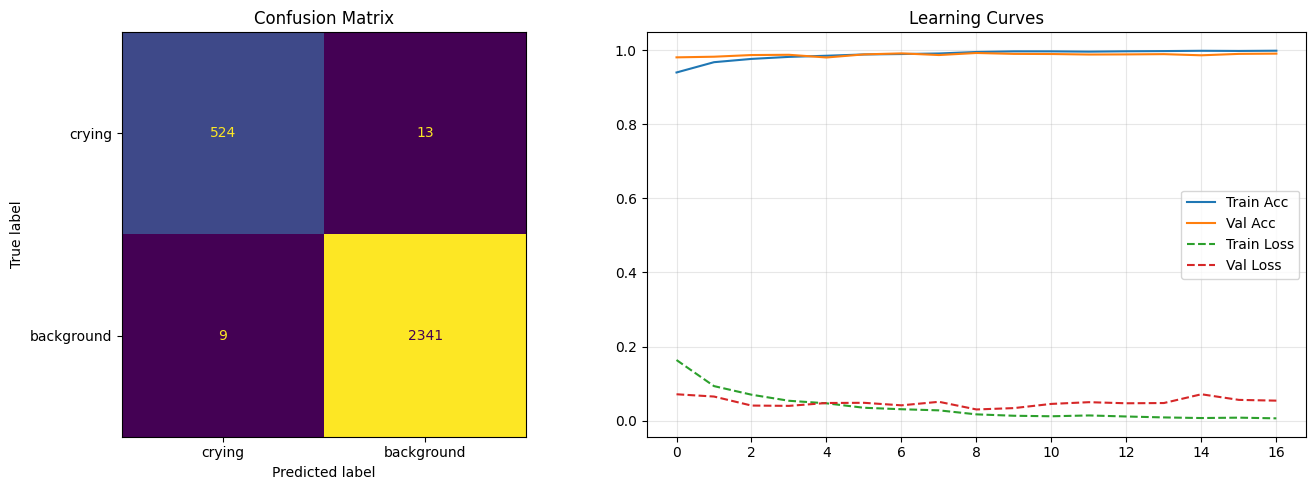


              precision    recall  f1-score   support

      crying       0.98      0.98      0.98       537
  background       0.99      1.00      1.00      2350

    accuracy                           0.99      2887
   macro avg       0.99      0.99      0.99      2887
weighted avg       0.99      0.99      0.99      2887

AUC crying: 0.9974

📊 השפעת threshold על crying recall:
  threshold=0.30 → crying precision=0.974, recall=0.985
  threshold=0.35 → crying precision=0.974, recall=0.983
  threshold=0.40 → crying precision=0.978, recall=0.980
  threshold=0.45 → crying precision=0.981, recall=0.980
  threshold=0.50 → crying precision=0.983, recall=0.976

✅ Gap train/val = 0.008 — נראה תקין.


In [17]:
# ===== תא 14: הערכת המודל =====
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, precision_score, recall_score
import numpy as np

CATEGORIES = ['crying', 'background']

test_loss, test_acc = model.evaluate(X_test, y_cat_test, verbose=0)
print(f'🎯 Test Accuracy: {test_acc*100:.2f}%')
print(f'📉 Test Loss:     {test_loss:.4f}')

y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_cat_test,   axis=1)

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORIES)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].plot(history.history['loss'],         label='Train Loss', linestyle='--')
axes[1].plot(history.history['val_loss'],     label='Val Loss',   linestyle='--')
axes[1].set_title('Learning Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_OUT, 'evaluation.png'), dpi=150)
plt.show()

print('\n' + classification_report(y_true, y_pred, target_names=CATEGORIES))

auc = roc_auc_score((y_true == 0).astype(int), y_pred_probs[:,0])
print(f'AUC crying: {auc:.4f}')

print('\n📊 השפעת threshold על crying recall:')
for thresh in [0.3, 0.35, 0.4, 0.45, 0.5]:
    pred_t = (y_pred_probs[:,0] >= thresh).astype(int)
    p = precision_score(y_true == 0, pred_t)
    r = recall_score(y_true == 0, pred_t)
    print(f'  threshold={thresh:.2f} → crying precision={p:.3f}, recall={r:.3f}')

train_acc_final = history.history['accuracy'][-1]
val_acc_final   = history.history['val_accuracy'][-1]
gap = train_acc_final - val_acc_final
if gap > 0.05:
    print(f'\n⚠️  Gap train/val = {gap:.3f} — ייתכן overfitting.')
else:
    print(f'\n✅ Gap train/val = {gap:.3f} — נראה תקין.')


## תא 15: שמירה + העתקה ל-Drive


In [18]:
# ===== תא 15: שמירת המודל + העתקה ל-Google Drive =====
import shutil

# שמירת המודל הסופי
MODEL_FINAL = os.path.join(MODELS_OUT, 'sos_model.keras')
model.save(MODEL_FINAL)
print(f'✅ מודל נשמר: {MODEL_FINAL}')
print(f'✅ norm_stats נשמר: {os.path.join(MODELS_OUT, "norm_stats.json")}')

# העתקה ל-Google Drive (אם mount)
try:
    from google.colab import drive
    # Drive אמור להיות כבר mounted מתא קודם — אם לא, יתבקש mount
    drive_out = '/content/drive/MyDrive/SOS_Model_v2'
    os.makedirs(drive_out, exist_ok=True)
    shutil.copy2(MODEL_FINAL, drive_out)
    shutil.copy2(os.path.join(MODELS_OUT, 'norm_stats.json'), drive_out)
    shutil.copy2(os.path.join(MODELS_OUT, 'evaluation.png'), drive_out)
    print(f'✅ הועתק ל-Drive: {drive_out}')
except Exception as e:
    print(f'⚠️  לא הועתק ל-Drive ({e})')
    print('   הורידי ידנית מ-Files panel בצד שמאל:')
    print(f'   {MODEL_FINAL}')
    print(f'   {os.path.join(MODELS_OUT, "norm_stats.json")}')

print('\n📋 לאחר ההורדה, העתיקי את הקבצים ל:')
print('   SOS-Audio-Detection/models/sos_model.keras')
print('   SOS-Audio-Detection/models/norm_stats.json')


✅ מודל נשמר: /content/models/sos_model.keras
✅ norm_stats נשמר: /content/models/norm_stats.json
✅ הועתק ל-Drive: /content/drive/MyDrive/SOS_Model_v2

📋 לאחר ההורדה, העתיקי את הקבצים ל:
   SOS-Audio-Detection/models/sos_model.keras
   SOS-Audio-Detection/models/norm_stats.json


In [19]:
from google.colab import files

files.download('/content/models/sos_model_best.keras')
files.download('/content/models/norm_stats.json')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>